- using print(df.isna().sum()) a lot, because we want to make sure, we clean up all the NA values

- header=0 means that the headers for the variable names are to be found in the first row (note that 0 means the first row in Python)
sep="," means that "," is used as the separator between the values. This is because we are using the file type .csv (comma separated values)

- When we load a data set using Pandas, all blank cells are automatically converted into "NaN" values.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import os

In [3]:
df = pd.read_csv('bookings.csv', header=0, sep=",")

In [21]:
df.dtypes

Date                                  object
Time                                  object
Booking ID                            object
Booking Status                        object
Customer ID                           object
Vehicle Type                          object
Pickup Location                       object
Drop Location                         object
Avg VTAT                             float64
Avg CTAT                             float64
Cancelled Rides by Customer          float64
Reason for cancelling by Customer     object
Cancelled Rides by Driver            float64
Driver Cancellation Reason            object
Incomplete Rides                     float64
Incomplete Rides Reason               object
Booking Value                        float64
Ride Distance                        float64
Driver Ratings                       float64
Customer Rating                      float64
Payment Method                        object
dtype: object

In [ ]:
df.shape

(6162, 21)

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6162 entries, 0 to 6161
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Date                               6162 non-null   object 
 1   Time                               6162 non-null   object 
 2   Booking ID                         6162 non-null   object 
 3   Booking Status                     6162 non-null   object 
 4   Customer ID                        6162 non-null   object 
 5   Vehicle Type                       6162 non-null   object 
 6   Pickup Location                    6162 non-null   object 
 7   Drop Location                      6162 non-null   object 
 8   Avg VTAT                           5747 non-null   float64
 9   Avg CTAT                           4226 non-null   float64
 10  Cancelled Rides by Customer        440 non-null    float64
 11  Reason for cancelling by Customer  440 non-null    objec

In [6]:
print(df["Booking Status"].value_counts())

Booking Status
Completed                3836
Cancelled by Driver      1081
Cancelled by Customer     440
No Driver Found           415
Incomplete                390
Name: count, dtype: int64


In [7]:
print(df.isna().sum())

Date                                    0
Time                                    0
Booking ID                              0
Booking Status                          0
Customer ID                             0
Vehicle Type                            0
Pickup Location                         0
Drop Location                           0
Avg VTAT                              415
Avg CTAT                             1936
Cancelled Rides by Customer          5722
Reason for cancelling by Customer    5722
Cancelled Rides by Driver            5081
Driver Cancellation Reason           5081
Incomplete Rides                     5772
Incomplete Rides Reason              5772
Booking Value                        1937
Ride Distance                        1937
Driver Ratings                       2327
Customer Rating                      2327
Payment Method                       1937
dtype: int64


In [8]:
# check all the data type for each column
for col in df.columns:
    print(df[col].dtype)

object
object
object
object
object
object
object
object
float64
float64
float64
object
float64
object
float64
object
float64
float64
float64
float64
object


In [9]:
numeric_col = [col for col in df.columns if df[col].dtype != 'object']
print(numeric_col)

['Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer', 'Cancelled Rides by Driver', 'Incomplete Rides', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating']


In [10]:
# print out the header
print(df.head(0))
print('\n')
print(df.columns.tolist())

Empty DataFrame
Columns: [Date, Time, Booking ID, Booking Status, Customer ID, Vehicle Type, Pickup Location, Drop Location, Avg VTAT, Avg CTAT, Cancelled Rides by Customer, Reason for cancelling by Customer, Cancelled Rides by Driver, Driver Cancellation Reason, Incomplete Rides, Incomplete Rides Reason, Booking Value, Ride Distance, Driver Ratings, Customer Rating, Payment Method]
Index: []

[0 rows x 21 columns]


['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer', 'Reason for cancelling by Customer', 'Cancelled Rides by Driver', 'Driver Cancellation Reason', 'Incomplete Rides', 'Incomplete Rides Reason', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Payment Method']


<Axes: >

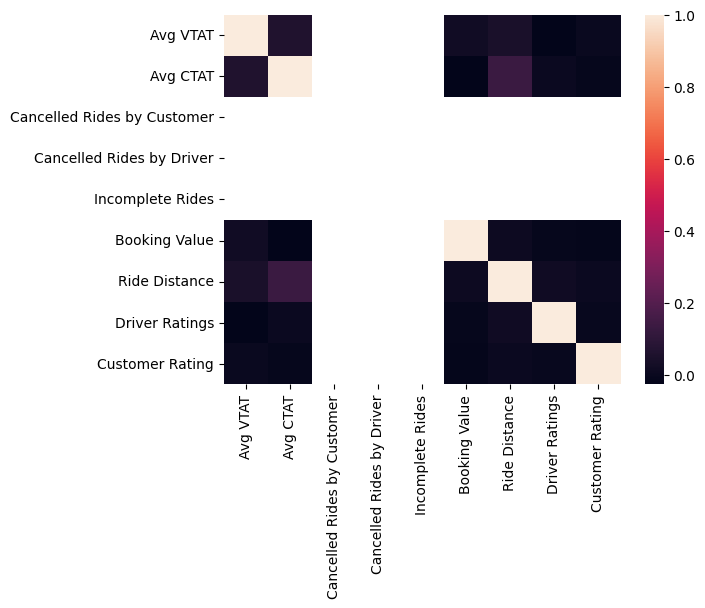

In [11]:
# After calling sns.heatmap(), it is necessary to call plt.show()
# to display the plot, especially in scripts or environments 
#  plots are not automatically rendered.
sns.heatmap(df[numeric_col].corr())


In [12]:
df[numeric_col].corr()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
Avg VTAT,1.000000,0.058588,NaN,NaN,NaN,0.017328,0.044187,-0.026885,-0.002306
Avg CTAT,0.058588,1.000000,NaN,NaN,NaN,-0.024088,0.132186,0.003990,-0.011267
Cancelled Rides by Customer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cancelled Rides by Driver,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Incomplete Rides,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Booking Value,0.017328,-0.024088,NaN,NaN,NaN,1.000000,0.006714,-0.014113,-0.015790
Ride Distance,0.044187,0.132186,NaN,NaN,NaN,0.006714,1.000000,0.014803,0.004214
Driver Ratings,-0.026885,0.003990,NaN,NaN,NaN,-0.014113,0.014803,1.000000,-0.005100
Customer Rating,-0.002306,-0.011267,NaN,NaN,NaN,-0.015790,0.004214,-0.005100,1.000000


In [13]:
plt.show()

In [14]:
print(df.columns.tolist())

['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer', 'Reason for cancelling by Customer', 'Cancelled Rides by Driver', 'Driver Cancellation Reason', 'Incomplete Rides', 'Incomplete Rides Reason', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Payment Method']


In [15]:
# https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html
imp_mean = SimpleImputer(missing_values = np.nan, strategy = 'mean')
target_columns = [
    'Avg VTAT',
    'Avg CTAT',
    'Booking Value',
    'Ride Distance',
    'Driver Ratings',
    'Customer Rating'

]

In [16]:
df[target_columns] = imp_mean.fit_transform(df[target_columns])

In [17]:
print(df.isna().sum())

Date                                    0
Time                                    0
Booking ID                              0
Booking Status                          0
Customer ID                             0
Vehicle Type                            0
Pickup Location                         0
Drop Location                           0
Avg VTAT                                0
Avg CTAT                                0
Cancelled Rides by Customer          5722
Reason for cancelling by Customer    5722
Cancelled Rides by Driver            5081
Driver Cancellation Reason           5081
Incomplete Rides                     5772
Incomplete Rides Reason              5772
Booking Value                           0
Ride Distance                           0
Driver Ratings                          0
Customer Rating                         0
Payment Method                       1937
dtype: int64


In [18]:
# value_count, By default, rows that contain any NA values are omitted from the result.
print(df["Cancelled Rides by Driver"].value_counts())

Cancelled Rides by Driver
1.0    1081
Name: count, dtype: int64


In [19]:
df["Cancelled Rides by Driver"] = df["Cancelled Rides by Driver"].replace(np.nan, 0)

# value_count, By default, rows that contain any NA values are omitted from the result.
total = df["Cancelled Rides by Driver"].value_counts()

In [20]:
print(total)

Cancelled Rides by Driver
0.0    5081
1.0    1081
Name: count, dtype: int64
